# Pruebas de hipótesis de las medidas de los componentes ERP

## Funciones

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.sandbox.stats.multicomp import multipletests

In [6]:
data_subjects_erps = pd.read_csv('data_subjects.csv')
data_subjects_erps.head()

,subject,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,mean_amplitude_co,mean_amplitude_in,mean_amplitude_dif,peak_amplitude_co,peak_amplitude_in,peak_amplitude_dif,peak_latency_co,peak_latency_in
0,21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,0.586812,0.537628,0.049184,-0.102898,0.217525,-1.114495,0.160156,0.250000
1,21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,0.463325,1.170137,-0.706813,0.168540,0.453635,-1.258774,0.210938,0.148438
2,21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,-4.757545,-3.940181,-0.817364,-6.066593,-5.288409,-2.164558,0.199219,0.207031
3,21105,excombatant,exparamilitar,yes,high,48,M,8,D,0.258352,0.410431,0.404159,0.006272,-0.301943,-0.690351,-0.827955,0.148438,0.167969
4,21107,excombatant,exguerrilla,no,high,25,M,11,D,-0.119566,0.256688,0.392556,-0.135867,0.012856,0.149298,-0.477868,0.230469,0.148438


In [7]:
data_subjects_erps = data_subjects_erps[
    data_subjects_erps['type'] != 'excombatant'
]

data_subjects_erps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 29 to 86
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject             37 non-null     int64  
 1   type                37 non-null     object 
 2   group               37 non-null     object 
 3   victim_self         35 non-null     object 
 4   exposure_level      37 non-null     object 
 5   age                 37 non-null     int64  
 6   gender              37 non-null     object 
 7   scholarship         37 non-null     int64  
 8   laterality          37 non-null     object 
 9   IAT_score           36 non-null     float64
 10  mean_amplitude_co   37 non-null     float64
 11  mean_amplitude_in   37 non-null     float64
 12  mean_amplitude_dif  37 non-null     float64
 13  peak_amplitude_co   37 non-null     float64
 14  peak_amplitude_in   37 non-null     float64
 15  peak_amplitude_dif  37 non-null     float64
 16  peak_latency_c

## Latencia

In [64]:
# 2. Transformar de formato ancho (wide) a largo (long)
# Esto es necesario para tratar "peak_latency_co" y "peak_latency_in" como niveles de un factor
df_long = pd.melt(data_subjects_erps, 
                  id_vars=['subject', 'type', 'age', 'gender', 'scholarship'], 
                  value_vars=['peak_latency_co', 'peak_latency_in'], 
                  var_name='condition', 
                  value_name='latency')

# Limpiar los nombres de la columna 'condition' para que sean más legibles
df_long['condition'] = df_long['condition'].replace({
    'peak_latency_co': 'congruent', 
    'peak_latency_in': 'incongruent'
})

# 2. Transformación Logarítmica
df_long['log_latency'] = np.log(df_long['latency'])

#scaler = StandardScaler()
#df_long[['age', 'scholarship']] = scaler.fit_transform(df_long[['age', 'scholarship']])

# 3. Definir y ajustar el Modelo Lineal Mixto (Mixed ANCOVA)
# La fórmula sigue la estructura: VD ~ Factor1 * Factor2 + Covariables
# 'groups' define que las medidas están anidadas dentro de cada sujeto
formula = "log_latency ~ condition * type + age + gender + scholarship"
model = smf.mixedlm(formula, df_long, groups=df_long["subject"])
result = model.fit(method='bfgs')
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         log_latency
No. Observations:           74              Method:                     REML       
No. Groups:                 37              Scale:                      0.0111     
Min. group size:            2               Log-Likelihood:             28.2848    
Max. group size:            2               Converged:                  Yes        
Mean group size:            2.0                                                    
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                               -1.933    0.105 -18.331 0.000 -2.140 -1.726
condition[T.incongruent]                 0.098    0.038   2.552 0.011  0.023  0.174
type[T.victim] 

c:\Users\Usuario\repos\iat-eeg\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


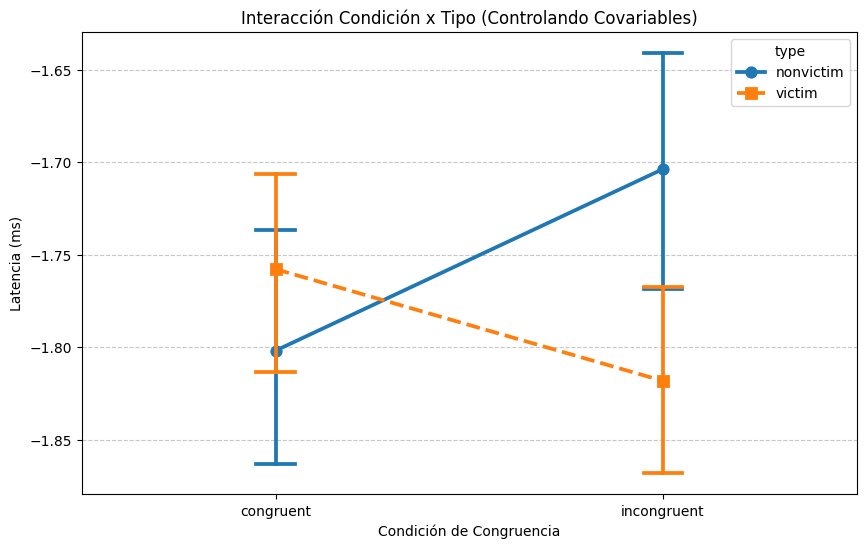

In [65]:
# 5. Visualización de la interacción
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_long, x="condition", y="log_latency", hue="type", 
              markers=["o", "s"], linestyles=["-", "--"], capsize=.1)

plt.title("Interacción Condición x Tipo (Controlando Covariables)")
plt.ylabel("Latencia (ms)")
plt.xlabel("Condición de Congruencia")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Shapiro-Wilk Test: W=0.9587, p-value=0.0165


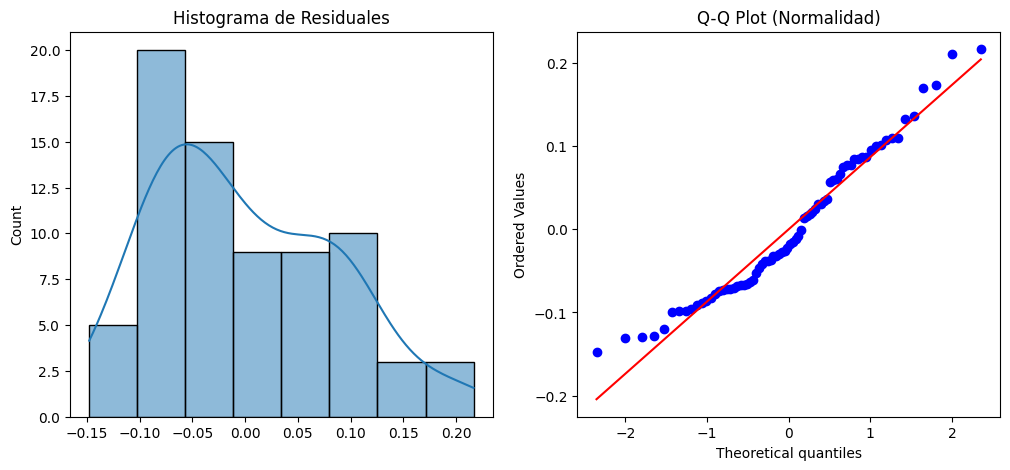

In [66]:
# --- SUPUESTO 1: NORMALIDAD DE LOS RESIDUALES ---
residuals = result.resid

# Prueba de Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# Gráficos de Normalidad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(residuals, kde=True, ax=ax1)
ax1.set_title("Histograma de Residuales")

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot (Normalidad)")
plt.show()


--- Test de Levene (Comparación entre grupos) ---
Estadístico: 0.2573, p-valor: 0.6135


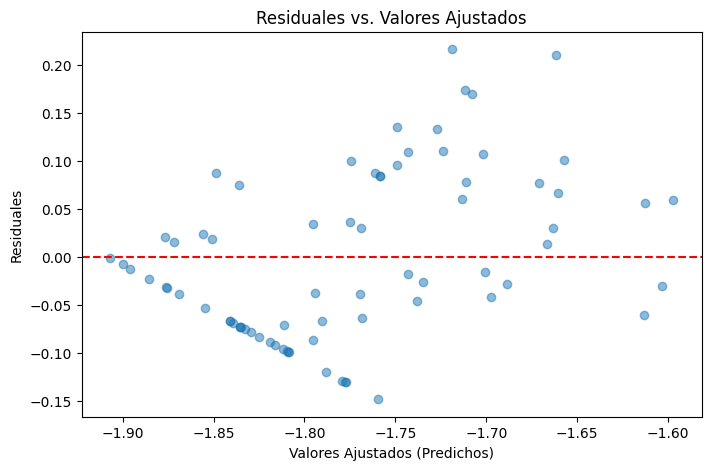

In [67]:
# 3. TEST DE LEVENE (Por Grupo: victim vs nonvictim)
# Comparamos si la varianza de la latencia es igual entre los dos grupos
group_v = df_long[df_long['type'] == 'victim']['log_latency']
group_nv = df_long[df_long['type'] == 'nonvictim']['log_latency']

levene_test = stats.levene(group_v, group_nv)
print("\n--- Test de Levene (Comparación entre grupos) ---")
print(f"Estadístico: {levene_test.statistic:.4f}, p-valor: {levene_test.pvalue:.4f}")

# --- SUPUESTO 2: HOMOCEDASTICIDAD (Varianza Constante) ---
fitted = result.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados (Predichos)")
plt.ylabel("Residuales")
plt.title("Residuales vs. Valores Ajustados")
plt.show()

In [68]:
# --- SUPUESTO 3: HOMOGENEIDAD DE PENDIENTES DE REGRESIÓN ---
# Para este supuesto, verificamos si hay interacciones significativas entre 
# los factores (condition, type) y las covariables (age, scholarship).
# Si el p-valor de la interacción es > 0.05, el supuesto se cumple.

covariables = ['age', 'scholarship', 'gender']
for cov in covariables:
    print(f"\n--- Verificando Homogeneidad para: {cov} ---")
    formula_inter = f"log_latency ~ condition * type * {cov}"
    res_inter = smf.mixedlm(formula_inter, df_long, groups=df_long["subject"]).fit()
    
    # Extraemos solo las filas que contienen la interacción con la covariable
    p_values = res_inter.pvalues
    inter_p = p_values[p_values.index.str.contains(f':{cov}')]
    print(inter_p)


--- Verificando Homogeneidad para: age ---
condition[T.incongruent]:age                   0.163789
type[T.victim]:age                             0.956509
condition[T.incongruent]:type[T.victim]:age    0.192363
dtype: float64

--- Verificando Homogeneidad para: scholarship ---
condition[T.incongruent]:scholarship                   0.078500
type[T.victim]:scholarship                             0.091627
condition[T.incongruent]:type[T.victim]:scholarship    0.046232
dtype: float64

--- Verificando Homogeneidad para: gender ---
condition[T.incongruent]:gender[T.M]                   0.814886
type[T.victim]:gender[T.M]                             0.352540
condition[T.incongruent]:type[T.victim]:gender[T.M]    0.690741
dtype: float64


c:\Users\Usuario\repos\iat-eeg\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Usuario\repos\iat-eeg\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Usuario\repos\iat-eeg\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [69]:
#import numpy as np
#from statsmodels.stats.multitest import multipletests

# Definimos los contrastes basados en el orden de los coeficientes del modelo
# (Intercept, condition[T.in], type[T.victim], gender[T.M], condition:type, age, scholarship)
k_fe = len(result.fe_params)

def get_simple_effect(indices):
    L = np.zeros(k_fe)
    for i in indices: L[i] = 1
    test = result.t_test(L.reshape(1, -1))
    return float(test.pvalue)

# 1. No-víctimas: In vs Co
p1 = get_simple_effect([1]) 
# 2. Víctimas: In vs Co
p2 = get_simple_effect([1, 4]) 
# 3. Congruente: V vs NV
p3 = get_simple_effect([2])
# 4. Incongruente: V vs NV
p4 = get_simple_effect([2, 4])

# Aplicar corrección de Bonferroni
raw_p = [p1, p2, p3, p4]
_, p_corr, _, _ = multipletests(raw_p, method='bonferroni')

print(f"No-víctimas (In vs Co): p-corr = {p_corr[0]:.4f}")
print(f"Víctimas (In vs Co):    p-corr = {p_corr[1]:.4f}")

No-víctimas (In vs Co): p-corr = 0.0428
Víctimas (In vs Co):    p-corr = 0.2282


## Amplitud media

In [70]:
# 2. Transformar de formato ancho (wide) a largo (long)
# Esto es necesario para tratar "peak_latency_co" y "peak_latency_in" como niveles de un factor
df_long = pd.melt(data_subjects_erps, 
                  id_vars=['subject', 'type', 'age', 'gender', 'scholarship'], 
                  value_vars=['mean_amplitude_co', 'mean_amplitude_in'], 
                  var_name='condition', 
                  value_name='mean_amplitude')

# Limpiar los nombres de la columna 'condition' para que sean más legibles
df_long['condition'] = df_long['condition'].replace({
    'mean_amplitude_co': 'congruent', 
    'mean_amplitude_in': 'incongruent'
})

# 3. Definir y ajustar el Modelo Lineal Mixto (Mixed ANCOVA)
# La fórmula sigue la estructura: VD ~ Factor1 * Factor2 + Covariables
# 'groups' define que las medidas están anidadas dentro de cada sujeto
formula = "mean_amplitude ~ condition * type + age + gender + scholarship"
model = smf.mixedlm(formula, df_long, groups=df_long["subject"])
result = model.fit(method='bfgs')
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        mean_amplitude
No. Observations:         74             Method:                    REML          
No. Groups:               37             Scale:                     0.5108        
Min. group size:          2              Log-Likelihood:            -103.9497     
Max. group size:          2              Converged:                 Yes           
Mean group size:          2.0                                                     
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.319    0.807  1.634 0.102 -0.263  2.900
condition[T.incongruent]                -0.809    0.261 -3.100 0.002 -1.320 -0.298
type[T.victim]             

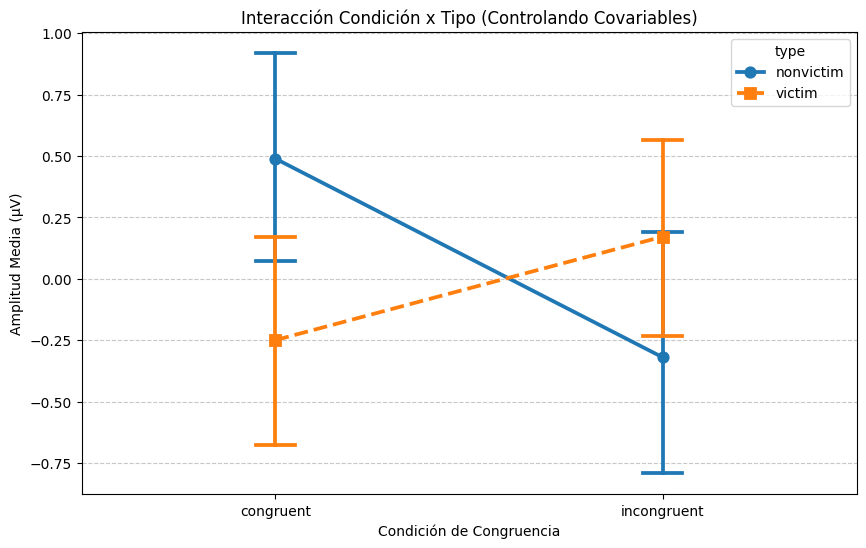

In [71]:
# 5. Visualización de la interacción
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_long, x="condition", y="mean_amplitude", hue="type", 
              markers=["o", "s"], linestyles=["-", "--"], capsize=.1)

plt.title("Interacción Condición x Tipo (Controlando Covariables)")
plt.ylabel("Amplitud Media (µV)")
plt.xlabel("Condición de Congruencia")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Shapiro-Wilk Test: W=0.9860, p-value=0.5897


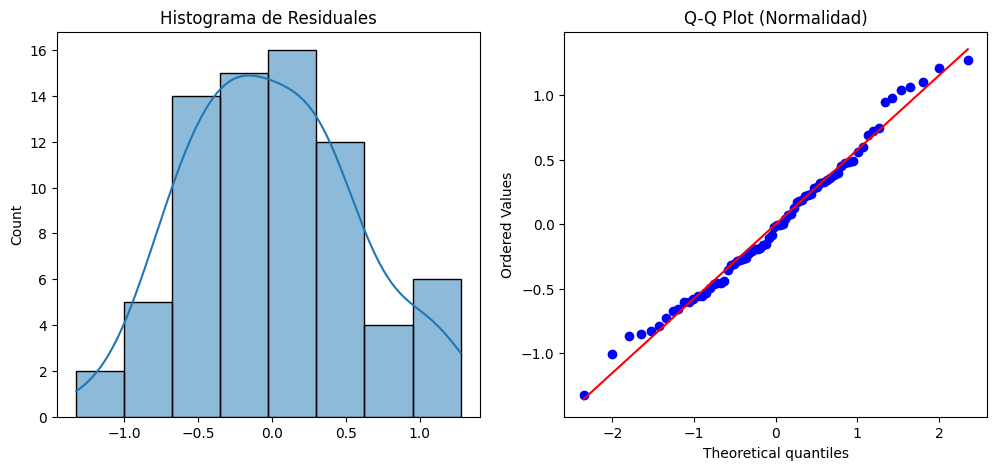

In [72]:
# --- SUPUESTO 1: NORMALIDAD DE LOS RESIDUALES ---
residuals = result.resid

# Prueba de Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# Gráficos de Normalidad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(residuals, kde=True, ax=ax1)
ax1.set_title("Histograma de Residuales")

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot (Normalidad)")
plt.show()


--- Test de Levene (Comparación entre grupos) ---
Estadístico: 0.0020, p-valor: 0.9649


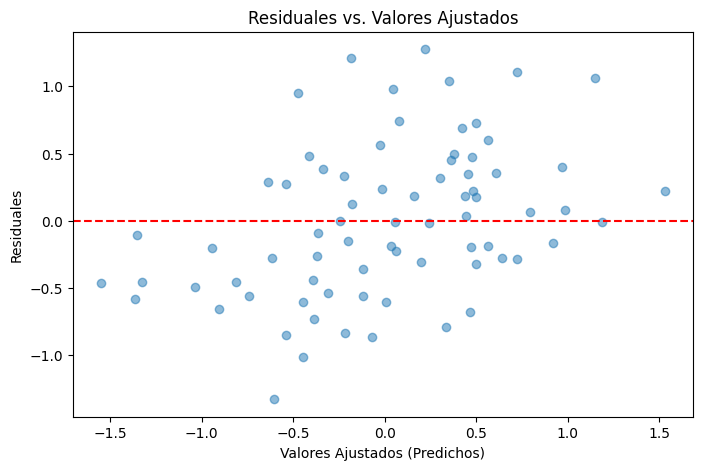

In [73]:
# --- SUPUESTO 2: HOMOCEDASTICIDAD (Varianza Constante) ---
# 3. TEST DE LEVENE (Por Grupo: victim vs nonvictim)
# Comparamos si la varianza de la latencia es igual entre los dos grupos
group_v = df_long[df_long['type'] == 'victim']['mean_amplitude']
group_nv = df_long[df_long['type'] == 'nonvictim']['mean_amplitude']

levene_test = stats.levene(group_v, group_nv)
print("\n--- Test de Levene (Comparación entre grupos) ---")
print(f"Estadístico: {levene_test.statistic:.4f}, p-valor: {levene_test.pvalue:.4f}")

fitted = result.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados (Predichos)")
plt.ylabel("Residuales")
plt.title("Residuales vs. Valores Ajustados")
plt.show()

In [74]:
# --- SUPUESTO 3: HOMOGENEIDAD DE PENDIENTES DE REGRESIÓN ---
# Para este supuesto, verificamos si hay interacciones significativas entre 
# los factores (condition, type) y las covariables (age, scholarship).
# Si el p-valor de la interacción es > 0.05, el supuesto se cumple.

covariables = ['age', 'scholarship', 'gender']
for cov in covariables:
    print(f"\n--- Verificando Homogeneidad para: {cov} ---")
    formula_inter = f"mean_amplitude ~ condition * type * {cov}"
    res_inter = smf.mixedlm(formula_inter, df_long, groups=df_long["subject"]).fit()
    
    # Extraemos solo las filas que contienen la interacción con la covariable
    p_values = res_inter.pvalues
    inter_p = p_values[p_values.index.str.contains(f':{cov}')]
    print(inter_p)


--- Verificando Homogeneidad para: age ---
condition[T.incongruent]:age                   0.011046
type[T.victim]:age                             0.177813
condition[T.incongruent]:type[T.victim]:age    0.011429
dtype: float64

--- Verificando Homogeneidad para: scholarship ---
condition[T.incongruent]:scholarship                   0.847272
type[T.victim]:scholarship                             0.114729
condition[T.incongruent]:type[T.victim]:scholarship    0.876586
dtype: float64

--- Verificando Homogeneidad para: gender ---
condition[T.incongruent]:gender[T.M]                   0.399057
type[T.victim]:gender[T.M]                             0.585874
condition[T.incongruent]:type[T.victim]:gender[T.M]    0.995906
dtype: float64


In [75]:
#import numpy as np
#from statsmodels.stats.multitest import multipletests

# Definimos los contrastes basados en el orden de los coeficientes del modelo
# (Intercept, condition[T.in], type[T.victim], gender[T.M], condition:type, age, scholarship)
k_fe = len(result.fe_params)

def get_simple_effect(indices):
    L = np.zeros(k_fe)
    for i in indices: L[i] = 1
    test = result.t_test(L.reshape(1, -1))
    return float(test.pvalue)

# 1. No-víctimas: In vs Co
p1 = get_simple_effect([1]) 
# 2. Víctimas: In vs Co
p2 = get_simple_effect([1, 4]) 
# 3. Congruente: V vs NV
p3 = get_simple_effect([2])
# 4. Incongruente: V vs NV
p4 = get_simple_effect([2, 4])

# Aplicar corrección de Bonferroni
raw_p = [p1, p2, p3, p4]
_, p_corr, _, _ = multipletests(raw_p, method='bonferroni')

print(f"No-víctimas (In vs Co): p-corr = {p_corr[0]:.4f}")
print(f"Víctimas (In vs Co):    p-corr = {p_corr[1]:.4f}")

No-víctimas (In vs Co): p-corr = 0.0077
Víctimas (In vs Co):    p-corr = 0.2024


## Análisis covariables

### Age

In [76]:
# Normalidad de age por type
pg.normality(
    data=data_subjects_erps, 
    dv='age', 
    group='type', 
    method='shapiro', 
    alpha=0.05
    )

,W,pval,normal
type,,,
nonvictim,0.958400,0.664618,True
victim,0.960358,0.496554,True


In [77]:
# Homocedasticity de age por type
pg.homoscedasticity(
    data=data_subjects_erps, 
    dv='age', 
    group='type', 
    method='levene', 
    alpha=0.05
    )

,W,pval,equal_var
levene,5.469744,0.025186,False


In [78]:
# ANOVA de age por type
pg.anova(
    data=data_subjects_erps, 
    dv='age', 
    between='type', 
    effsize='np2'
    )

,Source,ddof1,ddof2,F,p_unc,np2
0,type,1,35,4.973195,0.032254,0.124413


In [79]:
pg.welch_anova(data=data_subjects_erps, dv='age', between='type')

,Source,ddof1,ddof2,F,p_unc,np2
0,type,1,33.879831,6.112067,0.018607,0.124413


**Conclusión**: Hay diferencias significativas en la edad por tipo de actor.

### Scholarship

In [80]:
# Normalidad de scholarship por type
pg.normality(
    data=data_subjects_erps, 
    dv='scholarship', 
    group='type', 
    method='shapiro', 
    alpha=0.05
    )

,W,pval,normal
type,,,
nonvictim,0.766030,0.001392,False
victim,0.868774,0.007428,False


In [81]:
# Homocedasticity de scholarship por type
pg.homoscedasticity(
    data=data_subjects_erps, 
    dv='scholarship', 
    group='type', 
    method='levene', 
    alpha=0.05
    )

,W,pval,equal_var
levene,1.848278,0.182679,True


In [82]:
# Kruskal para scholarship por type
pg.kruskal(
    data=data_subjects_erps, 
    dv='scholarship', 
    between='type'
    )

,Source,ddof1,H,p_unc
Kruskal,type,1,1.495294,0.221397


**Conclusión**: No hay diferencias significativas en los años de estudio por tipo de actor.

### Sex

In [83]:
# prueba chi-squared type vs gender
contingency_table = pd.crosstab(
    data_subjects_erps['type'], 
    data_subjects_erps['gender']
    )

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2}, p-value: {p}, dof: {dof}")

Chi2: 13.455354020979021, p-value: 0.0002443079909029722, dof: 1


**Conclusión**: Sí hay diferencias significativas en el sexo por tipo de actor.